# Evaluating Model Robustness to Distribution Shift via SAM
**USC Viterbi — Hanchen Zou, Kaicheng Li, Siting Dai, Zhiqi Chen**

本 notebook 完整实现三个部分：
1. **PART 1** — 玩具损失函数上的 2D 等高线 + 3D 轨迹对比图
2. **PART 2** — 在 CIFAR-10 上训练 ResNet-18（SGD vs SAM）
3. **PART 3** — 在人工生成的 CIFAR-10-C 腐蚀数据上评估 OOD 鲁棒性

> ⚠️ **运行前确认**：Runtime → Change runtime type → Hardware accelerator → **GPU (T4)**

In [ ]:
# ============================================================
# CELL 1: 环境初始化
# ============================================================
# Prepared for CSCI 567 / USC Viterbi SAM Robustness Project
# References:
#   Foret et al. (2021) - SAM: Sharpness-Aware Minimization
#   Hendrycks & Dietterich (2019) - Benchmarking Neural Network Robustness

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import time
import warnings
warnings.filterwarnings('ignore')

# ---- 随机种子（保证结果可复现）----
torch.manual_seed(42)
np.random.seed(42)

# ---- 设备检测 ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected! Training will be very slow.')
    print('   Go to: Runtime > Change runtime type > GPU')

✅ Using device: cuda
   GPU: NVIDIA A100-SXM4-40GB
   Memory: 42.4 GB


---
## PART 1 — 玩具损失函数可视化（2D 等高线 & 3D 曲面）

### 损失函数设计说明
使用一个**弯曲峡谷形**损失函数：
$$f(w_1, w_2) = \frac{1}{2}w_1^2 + c\cdot(w_2 - 0.2 w_1^2)^2$$

- 该函数有一条**弯曲的窄谷**，SGD 由于各方向曲率不同会走弯曲路径  
- SAM 通过在**最坏邻域处**计算梯度，路径与 SGD 有明显差异  
- 最小值在 $(0, 0)$，从 $(4, 3)$ 出发可以观察到完整轨迹

### 参数调试指南
| 参数 | 默认值 | 效果说明 |
|------|--------|----------|
| `VALLEY_SHARPNESS` | 5.0 | **越大**峡谷越窄越陡，两条路径差异**越明显** |
| `SAM_RHO_TOY` | 0.5 | SAM 扰动半径。**越大**轨迹差异**越大**，但可能不收敛 |
| `SGD_LR_TOY` | 0.06 | SGD 学习率。**过大**则发散 |
| `N_STEPS_TOY` | 80 | 迭代步数。增加可看到收敛全过程 |
| `START_POINT` | [4,3] | 起始点。偏轴（非对称）起始让轨迹更丰富 |

**如果两条轨迹太相似**：↑ `VALLEY_SHARPNESS` (→ 20-50) 或 ↑ `SAM_RHO_TOY` (→ 0.8-1.2)  
**如果 SAM 轨迹发散**：↓ `SAM_RHO_TOY` (→ 0.2-0.4) 或 ↓ `SGD_LR_TOY`

In [ ]:
# ============================================================
# CELL 2: 玩具损失函数定义与轨迹计算
# ============================================================

# ====================================================================
# ★★★  可调参数区域  ★★★
# ====================================================================
VALLEY_SHARPNESS = 50.0   # 峡谷陡峭程度。调大(10-50)可让路径差异更明显
                          # 调小(1-3)让两条路径更接近
SGD_LR_TOY  = 0.08        # SGD 学习率。稳定范围约 0.01 ~ 0.1
SAM_LR_TOY  = 0.08        # SAM 学习率（通常与SGD相同，公平对比）
SAM_RHO_TOY = 0.08         # SAM 扰动半径 ρ。调大(0.8-1.5)路径差异更大
                          # 调小(0.1-0.3)路径接近 SGD
N_STEPS_TOY = 100          # 优化迭代步数。增加(100-150)可观察更完整的收敛
START_POINT = np.array([4.0, 1.0])  # 起始点。试试 [3,4], [5,1], [-4,3]
# ====================================================================


def toy_loss(w1, w2):
    """
    弯曲峡谷损失函数：f(w1,w2) = 0.5*w1^2 + c*(w2 - 0.2*w1^2)^2
    - 第一项：宽浅碗形（w1 方向）
    - 第二项：沿抛物线弯曲的窄谷（w2 方向随 w1 变化）
    - 全局最小值在 (0, 0)
    """
    valley = w2 - 0.2 * w1**2
    return 0.5 * w1**2 + VALLEY_SHARPNESS * valley**2


def toy_grad(w):
    """toy_loss 的解析梯度"""
    w1, w2 = w[0], w[1]
    valley = w2 - 0.2 * w1**2
    df_dw1 = w1 + VALLEY_SHARPNESS * 2 * valley * (-0.4 * w1)
    df_dw2 = VALLEY_SHARPNESS * 2 * valley
    return np.array([df_dw1, df_dw2])


def run_sgd_toy(w_init, lr, n_steps):
    """
    标准梯度下降：w_{t+1} = w_t - lr * ∇f(w_t)

    参数调试:
    - lr 增大 → 更快但可能振荡；lr 减小 → 更稳但轨迹步数更多
    """
    w = w_init.copy().astype(float)
    path = [w.copy()]
    for _ in range(n_steps):
        g = toy_grad(w)
        # 梯度裁剪：防止步长过大（与 PyTorch 训练中 clip_grad_norm_ 同理）
        gn = np.linalg.norm(g)
        if gn > 10.0:
            g = g * 10.0 / gn
        w = w - lr * g
        path.append(w.copy())
    return np.array(path)


def run_sam_toy(w_init, lr, rho, n_steps):
    """
    SAM（Sharpness-Aware Minimization）玩具实现：

    每步分两个阶段：
    1. 扰动阶段（First Step）：
       ê = ρ * g / ‖g‖           # 沿梯度方向走 ρ 步
       ŵ = w + ê               # 到达局部最陡点

    2. 更新阶段（Second Step）：
       g_hat = ∇f(ŵ)           # 在最陡点处计算梯度
       w = w - lr * g_hat      # 用该梯度更新原点

    参数调试:
    - rho 增大 → 扰动更大，路径更不同于 SGD；但太大可能不稳定
    - rho=0 → 等价于 SGD
    - 通常 rho ∈ [0.1, 1.0]
    """
    w = w_init.copy().astype(float)
    path = [w.copy()]
    for _ in range(n_steps):
        # --- First Step: 计算扰动点 ---
        g = toy_grad(w)
        gn = np.linalg.norm(g) + 1e-12  # 防止除零
        e_w = rho * g / gn               # 扰动方向（单位梯度方向 × ρ）
        w_hat = w + e_w                  # 到最坏邻域点

        # --- Second Step: 在扰动点处计算梯度并更新 ---
        g_hat = toy_grad(w_hat)
        ghn = np.linalg.norm(g_hat)
        if ghn > 10.0:
            g_hat = g_hat * 10.0 / ghn  # 梯度裁剪
        w = w - lr * g_hat              # 注意：从原来的 w 更新，不是从 w_hat
        path.append(w.copy())
    return np.array(path)


# ---- 运行优化器，获取轨迹 ----
sgd_path_toy = run_sgd_toy(START_POINT, SGD_LR_TOY, N_STEPS_TOY)
sam_path_toy = run_sam_toy(START_POINT, SAM_LR_TOY, SAM_RHO_TOY, N_STEPS_TOY)

# 计算最终损失
sgd_final_loss = toy_loss(*sgd_path_toy[-1])
sam_final_loss = toy_loss(*sam_path_toy[-1])
max_separation = max(np.linalg.norm(sgd_path_toy[i] - sam_path_toy[i])
                     for i in range(len(sgd_path_toy)))

print(f'SGD 最终位置: [{sgd_path_toy[-1][0]:.4f}, {sgd_path_toy[-1][1]:.4f}]')
print(f'SGD 最终损失: {sgd_final_loss:.6f}')
print(f'SAM 最终位置: [{sam_path_toy[-1][0]:.4f}, {sam_path_toy[-1][1]:.4f}]')
print(f'SAM 最终损失: {sam_final_loss:.6f}')
print(f'轨迹最大分离距离: {max_separation:.4f}')
print()
print('💡 如果「轨迹最大分离距离」< 0.5，说明两条路径太相似。')
print('   请增大 VALLEY_SHARPNESS 或 SAM_RHO_TOY')

SGD 最终位置: [0.0112, 0.2679]
SGD 最终损失: 3.587058
SAM 最终位置: [0.0055, 0.2552]
SAM 最终损失: 3.255405
轨迹最大分离距离: 0.2211

💡 如果「轨迹最大分离距离」< 0.5，说明两条路径太相似。
   请增大 VALLEY_SHARPNESS 或 SAM_RHO_TOY


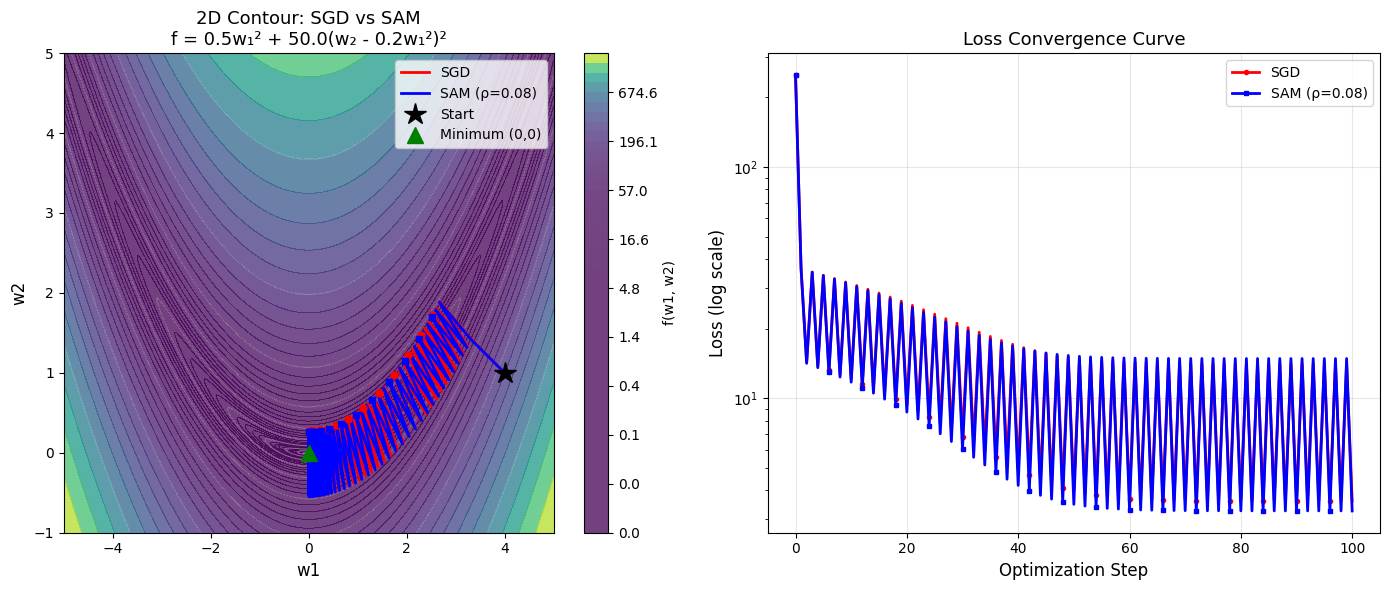

图已保存为 2d_contour_sgd_vs_sam.png


In [ ]:
# ============================================================
# CELL 3: 2D 等高线图 + 优化轨迹
# （与参考 notebook 风格保持一致）
# ============================================================

# ---- 构建网格 ----
w1_grid = np.linspace(-5, 5, 200)
w2_grid = np.linspace(-1, 5, 200)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = toy_loss(W1, W2)

# ---- 绘制 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 左图：等高线 filled contour ---
ax = axes[0]
# 对数间距等高线：让低值区域细节更清晰
levels = np.logspace(np.log10(max(Z.min(), 0.01)), np.log10(Z.max()), 50)
cf = ax.contourf(W1, W2, Z, levels=levels, cmap='viridis', alpha=0.75)
cs = ax.contour(W1, W2, Z, levels=levels[::5],
                colors='white', alpha=0.4, linewidths=0.7)
plt.colorbar(cf, ax=ax, label='f(w1, w2)')

# 绘制轨迹（每隔若干步标记一个点，避免过于密集）
step_mark = max(1, N_STEPS_TOY // 15)  # 每隔 step_mark 步标一个圆点
ax.plot(sgd_path_toy[:, 0], sgd_path_toy[:, 1],
        'r-', linewidth=2.0, zorder=5, label='SGD')
ax.plot(sgd_path_toy[::step_mark, 0], sgd_path_toy[::step_mark, 1],
        'ro', markersize=5, zorder=6)

ax.plot(sam_path_toy[:, 0], sam_path_toy[:, 1],
        'b-', linewidth=2.0, zorder=5, label=f'SAM (ρ={SAM_RHO_TOY})')
ax.plot(sam_path_toy[::step_mark, 0], sam_path_toy[::step_mark, 1],
        'bs', markersize=5, zorder=6)

# 标记起点和终点
ax.plot(*START_POINT, 'k*', markersize=16, zorder=7, label='Start')
ax.plot(0, 0, 'g^', markersize=12, zorder=7, label='Minimum (0,0)')

ax.set_xlabel('w1', fontsize=12)
ax.set_ylabel('w2', fontsize=12)
ax.set_title(f'2D Contour: SGD vs SAM\n'
             f'f = 0.5w₁² + {VALLEY_SHARPNESS}(w₂ - 0.2w₁²)²', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-5, 5)
ax.set_ylim(-1, 5)

# --- 右图：轨迹随时间的损失变化 ---
ax2 = axes[1]
sgd_losses = [toy_loss(*p) for p in sgd_path_toy]
sam_losses = [toy_loss(*p) for p in sam_path_toy]
steps = np.arange(len(sgd_losses))

ax2.semilogy(steps, sgd_losses, 'r-o', markersize=3, linewidth=2,
             markevery=step_mark, label='SGD')
ax2.semilogy(steps, sam_losses, 'b-s', markersize=3, linewidth=2,
             markevery=step_mark, label=f'SAM (ρ={SAM_RHO_TOY})')
ax2.set_xlabel('Optimization Step', fontsize=12)
ax2.set_ylabel('Loss (log scale)', fontsize=12)
ax2.set_title('Loss Convergence Curve', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2d_contour_sgd_vs_sam.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存为 2d_contour_sgd_vs_sam.png')

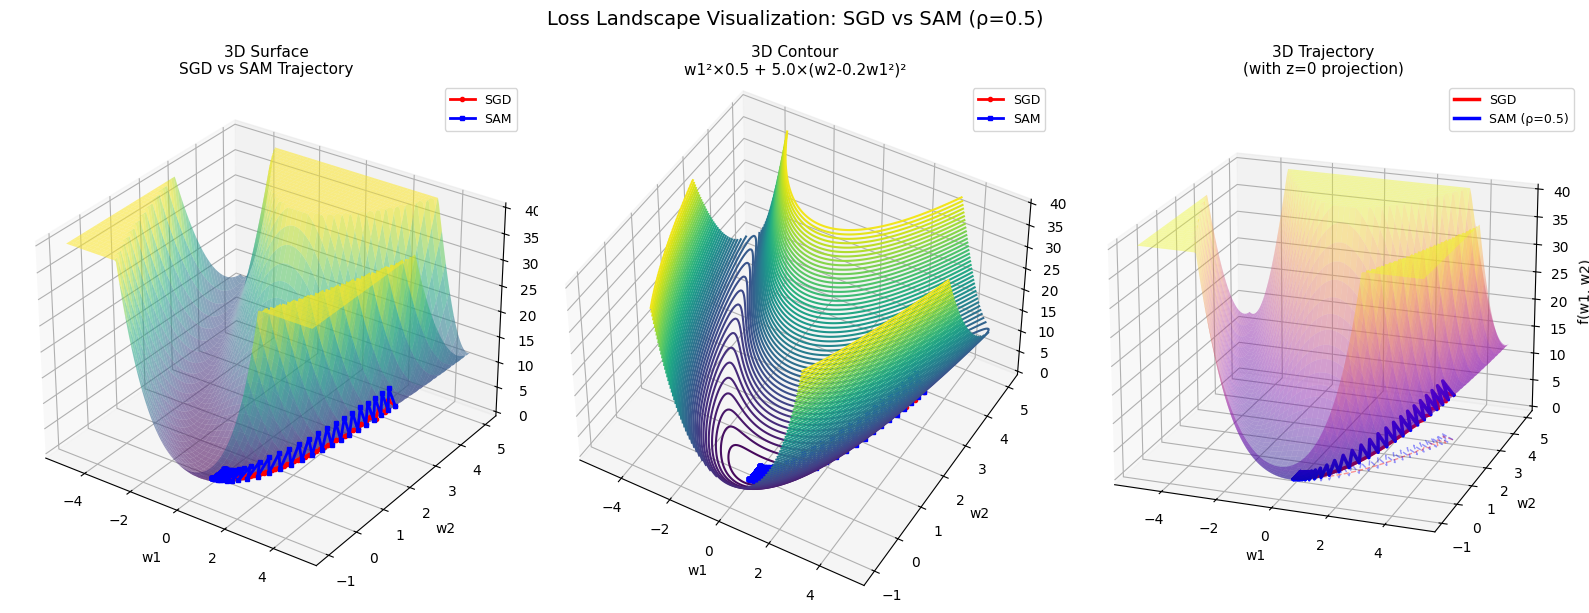

图已保存为 3d_surface_sgd_vs_sam.png


In [ ]:
# ============================================================
# CELL 4: 3D 曲面图 + 优化轨迹
# （与参考 notebook 中 ax.contour3D / ax.plot_surface 风格一致）
# ============================================================

# ---- 计算各轨迹点的 z 坐标（对应损失值）----
sgd_z = np.array([toy_loss(p[0], p[1]) for p in sgd_path_toy])
sam_z = np.array([toy_loss(p[0], p[1]) for p in sam_path_toy])

fig = plt.figure(figsize=(16, 6))

# ============================================================
# 左图：3D 曲面 + 轨迹投影
# ============================================================
ax1 = fig.add_subplot(131, projection='3d')

# 绘制 3D 曲面
# 参数调试：alpha 控制透明度(0-1)，cmap 控制颜色
surf = ax1.plot_surface(W1, W2, np.clip(Z, 0, 40),
                        cmap='viridis', alpha=0.55,
                        linewidth=0, antialiased=True)

# 绘制 3D 轨迹（悬浮在曲面上方）
ax1.plot(sgd_path_toy[:, 0], sgd_path_toy[:, 1], sgd_z,
         'r-o', markersize=3, linewidth=2.0, label='SGD', zorder=10)
ax1.plot(sam_path_toy[:, 0], sam_path_toy[:, 1], sam_z,
         'b-s', markersize=3, linewidth=2.0, label='SAM', zorder=10)

ax1.set_xlabel('w1')
ax1.set_ylabel('w2')
ax1.set_zlabel('f(w1, w2)')
ax1.set_title('3D Surface\nSGD vs SAM Trajectory', fontsize=11)
ax1.legend(fontsize=9, loc='upper right')
# 调整相机角度：elev=仰角，azim=方位角
# 如果轨迹被曲面遮挡，试试 elev=35, azim=-50 或 elev=25, azim=45
ax1.view_init(elev=30, azim=-55)

# ============================================================
# 中图：3D 等高线（与参考 notebook ax.contour3D 风格一致）
# ============================================================
ax2 = fig.add_subplot(132, projection='3d')

# contour3D 绘制三维等高线（与参考 notebook 完全相同的 API）
# 参数：50 是等高线条数，cmap 控制颜色
ax2.contour3D(W1, W2, np.clip(Z, 0, 40), 50, cmap='viridis')

# 在等高线图上叠加轨迹
ax2.plot(sgd_path_toy[:, 0], sgd_path_toy[:, 1], sgd_z,
         'r-o', markersize=3, linewidth=2, label='SGD')
ax2.plot(sam_path_toy[:, 0], sam_path_toy[:, 1], sam_z,
         'b-s', markersize=3, linewidth=2, label='SAM')

ax2.set_xlabel('w1')
ax2.set_ylabel('w2')
ax2.set_zlabel('f(w1,w2)')
ax2.set_title(f'3D Contour\nw1²×0.5 + {VALLEY_SHARPNESS}×(w2-0.2w1²)²', fontsize=11)
ax2.legend(fontsize=9)
ax2.view_init(elev=45, azim=-60)  # 俯视角度，更易看清路径

# ============================================================
# 右图：俯视 3D（相当于等高线 + 路径的 3D 版本）
# ============================================================
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(W1, W2, np.clip(Z, 0, 40),
                 cmap='plasma', alpha=0.4, linewidth=0)

# 将轨迹投影到 z=0 平面（阴影效果）
ax3.plot(sgd_path_toy[:, 0], sgd_path_toy[:, 1],
         np.zeros_like(sgd_z), 'r--', alpha=0.4, linewidth=1)
ax3.plot(sam_path_toy[:, 0], sam_path_toy[:, 1],
         np.zeros_like(sam_z), 'b--', alpha=0.4, linewidth=1)

# 实际 3D 轨迹
ax3.plot(sgd_path_toy[:, 0], sgd_path_toy[:, 1], sgd_z,
         'r-', linewidth=2.5, label='SGD')
ax3.plot(sam_path_toy[:, 0], sam_path_toy[:, 1], sam_z,
         'b-', linewidth=2.5, label=f'SAM (ρ={SAM_RHO_TOY})')

ax3.set_xlabel('w1')
ax3.set_ylabel('w2')
ax3.set_zlabel('f(w1, w2)')
ax3.set_title('3D Trajectory\n(with z=0 projection)', fontsize=11)
ax3.legend(fontsize=9)
ax3.view_init(elev=20, azim=-70)

plt.suptitle(f'Loss Landscape Visualization: SGD vs SAM (ρ={SAM_RHO_TOY})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('3d_surface_sgd_vs_sam.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存为 3d_surface_sgd_vs_sam.png')

---
## PART 2 — CIFAR-10 真实训练（ResNet-18: SGD vs SAM）

### 训练参数调试指南
| 参数 | 默认值 | 调试建议 |
|------|--------|----------|
| `EPOCHS` | 30 | 快速测试改 5；完整复现改 100-200 |
| `LR` | 0.1 | 标准 ResNet/SGD 设置；SAM 论文用相同值 |
| `SAM_RHO_TRAIN` | 0.05 | 论文推荐值；可试 0.01, 0.1, 0.2 |
| `BATCH_SIZE` | 128 | GPU OOM 时改 64 |
| `MOMENTUM` | 0.9 | 标准；通常不需要改 |
| `WEIGHT_DECAY` | 5e-4 | L2 正则；可试 1e-3 |

> ⏱️ 在 Colab T4 上，30 epochs 约 **5-8 分钟**（SGD）和 **10-15 分钟**（SAM）

In [ ]:
# ============================================================
# CELL 5: SAM 优化器完整实现
# 参考：Foret et al. (2021) "Sharpness-Aware Minimization for Efficiently
#       Improving Generalization"
# ============================================================

class SAM(torch.optim.Optimizer):
    """
    SAM（Sharpness-Aware Minimization）优化器

    核心思想：
    不直接最小化 L(w)，而是最小化最坏邻域的损失：
        min_w  max_{‖ε‖≤ρ}  L(w + ε)

    每次更新分两个 step：
    1. first_step()：找到最坏邻域点 ŵ = w + ρ*g/‖g‖，保存原始参数
    2. second_step()：在 ŵ 处计算梯度，恢复原始 w，用该梯度更新

    重要参数:
    - rho (ρ): 扰动半径，控制「平坦度」偏好的强度
      - 太小(→0): 退化为标准 SGD
      - 太大: 梯度估计不准，可能不收敛
      - 论文推荐: 0.05 (CIFAR-10), 0.01-0.2 是常用范围
    - adaptive: 若 True，使用 ASAM（自适应 SAM），对参数尺度不变
    """

    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0, f'rho 必须非负，当前值: {rho}'
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)

        # 使用基础优化器（通常是 SGD）来执行实际参数更新
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        """
        第一步：计算并施加扰动 e_w
        e_w = ρ * g / ‖g‖   （对 adaptive SAM 有所不同）
        w_hat = w + e_w
        同时将原始 w 保存在 self.state[p]["old_p"] 中
        """
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                self.state[p]['old_p'] = p.data.clone()  # 保存原始参数
                # Adaptive SAM: 对每个参数乘以 |p|（参数尺度归一化）
                e_w = (torch.pow(p, 2) if group['adaptive'] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)  # w = w + e_w （移动到最坏邻域）
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        """
        第二步：恢复原始参数，用扰动处的梯度做实际更新
        """
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.data = self.state[p]['old_p']  # 恢复到原始 w
        self.base_optimizer.step()  # 用 ŵ 处梯度更新 w
        if zero_grad:
            self.zero_grad()

    def step(self, closure=None):
        """
        不使用这个接口！SAM 需要两次前向传播。
        请使用 first_step + second_step 配合 closure 模式。
        """
        raise NotImplementedError(
            'SAM 不支持标准 .step()。\n'
            '请参考 train_one_epoch_sam() 中的训练循环写法。'
        )

    def _grad_norm(self):
        """计算所有参数梯度的全局 L2 范数（用于归一化扰动方向）"""
        shared_device = self.param_groups[0]['params'][0].device
        norm = torch.norm(
            torch.stack([
                ((torch.abs(p) if group['adaptive'] else 1.0) * p.grad).norm(p=2).to(shared_device)
                for group in self.param_groups
                for p in group['params']
                if p.grad is not None
            ]),
            p=2
        )
        return norm

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


print('✅ SAM 优化器类定义完成')
print(f'   论文推荐 rho = 0.05 (CIFAR-10/100)')

✅ SAM 优化器类定义完成
   论文推荐 rho = 0.05 (CIFAR-10/100)


In [ ]:
# ============================================================
# CELL 6: ResNet-18（CIFAR-10 适配版）
# ============================================================

def get_resnet18_cifar():
    """
    CIFAR-10 适配的 ResNet-18：

    标准 ResNet-18 为 ImageNet (224×224) 设计，直接用于 CIFAR-10 (32×32) 会
    因为 maxpool 和 stride=2 的 conv1 导致特征图过小。

    修改点：
    1. conv1: kernel 7→3, stride 2→1, padding 3→1（保留更多细节）
    2. maxpool: 替换为 Identity()（去掉，防止特征图太小）
    3. fc: 输出维度 1000→10（CIFAR-10 有 10 类）
    """
    model = models.resnet18(weights=None)  # 不加载预训练权重

    # 适配 CIFAR-10 的 32×32 输入
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # 去掉 maxpool
    model.fc = nn.Linear(512, 10)  # 10 分类

    return model


# 测试模型结构
_test_model = get_resnet18_cifar()
_test_input  = torch.randn(4, 3, 32, 32)
_test_output = _test_model(_test_input)
print(f'✅ ResNet-18 (CIFAR adapted)')
print(f'   输入: {_test_input.shape}')
print(f'   输出: {_test_output.shape}   (应为 [4, 10])')

# 参数量统计
n_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f'   可训练参数: {n_params/1e6:.2f}M')
del _test_model, _test_input, _test_output

✅ ResNet-18 (CIFAR adapted)
   输入: torch.Size([4, 3, 32, 32])
   输出: torch.Size([4, 10])   (应为 [4, 10])
   可训练参数: 11.17M


In [ ]:
# ============================================================
# CELL 7: 数据加载器（CIFAR-10）
# ============================================================

# ====================================================================
# ★★★  训练超参数（所有参数集中在此处修改）★★★
# ====================================================================
EPOCHS       = 30       # 训练轮数。快速测试用 5；完整实验用 100-200
BATCH_SIZE   = 128      # 批大小。GPU OOM 时改为 64
LR           = 0.1      # 初始学习率。标准 ResNet/SGD 设置
MOMENTUM     = 0.9      # SGD 动量。通常固定 0.9
WEIGHT_DECAY = 5e-4     # L2 正则化权重。可试 1e-3 或 1e-4
SAM_RHO_TRAIN = 0.05    # SAM 扰动半径。论文推荐 0.05；可试 0.01, 0.1, 0.2
# ====================================================================

# ---- 数据预处理 ----
# 训练集：使用标准数据增强
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),    # 随机裁剪（+4 像素padding）
    transforms.RandomHorizontalFlip(),       # 随机水平翻转
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),       # CIFAR-10 统计均值
        std =(0.2470, 0.2435, 0.2616)        # CIFAR-10 统计标准差
    )
])

# 测试集：只做归一化
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2470, 0.2435, 0.2616)
    )
])

# ---- 下载 & 加载数据集 ----
print('正在下载 CIFAR-10...')
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# ---- 数据加载器 ----
# num_workers=2 在 Colab 上通常最优（过多反而慢）
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'✅ 数据集加载完成')
print(f'   训练集: {len(train_dataset):,} 张图像 | {len(train_loader)} 批')
print(f'   测试集: {len(test_dataset):,}  张图像 | {len(test_loader)} 批')
print(f'   类别:   {CLASSES}')

正在下载 CIFAR-10...


100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


✅ 数据集加载完成
   训练集: 50,000 张图像 | 391 批
   测试集: 10,000  张图像 | 40 批
   类别:   ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [ ]:
# ============================================================
# CELL 8: 训练与评估函数
# ============================================================

def train_one_epoch_sgd(model, loader, optimizer, scheduler, criterion, device):
    """
    SGD 标准训练单轮：
    前向 → 计算损失 → 反向 → 更新参数
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)

    if scheduler is not None:
        scheduler.step()

    return total_loss / total, 100.0 * correct / total


def train_one_epoch_sam(model, loader, optimizer, scheduler, criterion, device):
    """
    SAM 训练单轮：每 batch 需要两次前向传播

    关键点：SAM 的训练循环与 SGD 不同！
    第一次前向/反向 → first_step（施加扰动）
    第二次前向/反向 → second_step（实际更新）

    注意：SAM 的计算量约是 SGD 的 2 倍（两次前向/反向），
    但实际 wall-clock 时间约 1.5-1.8 倍（由于第二次梯度计算开销更小）
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # ---- First forward-backward: 找到最坏邻域 ----
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()             # 计算 ∇L(w)
        optimizer.first_step(zero_grad=True)  # 保存 w，移动到 ŵ = w + ε

        # ---- Second forward-backward: 在 ŵ 处计算梯度 ----
        criterion(model(images), labels).backward()  # 计算 ∇L(ŵ)
        optimizer.second_step(zero_grad=True)        # 恢复 w，用 ∇L(ŵ) 更新

        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)

    if scheduler is not None:
        scheduler.step()

    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """标准评估函数（无梯度）"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


def train_full(optimizer_name, model, optimizer, scheduler, train_loader,
               test_loader, epochs, device):
    """
    完整训练循环，记录训练/测试指标
    返回: dict 包含 train_loss, train_acc, test_loss, test_acc
    """
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [],
                'test_loss':  [], 'test_acc':  []}

    train_fn = (train_one_epoch_sam if optimizer_name == 'SAM'
                else train_one_epoch_sgd)

    print(f'\n{"="*55}')
    print(f'  训练 {optimizer_name} 模型 | {epochs} epochs')
    print(f'{"="*55}')
    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8}')
    print(f'{"-"*55}')

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_fn(model, train_loader, optimizer,
                                    scheduler, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        elapsed = time.time() - t0
        eta = elapsed / epoch * (epochs - epoch)
        print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | '
              f'{te_loss:>9.4f} | {te_acc:>7.2f}%'
              + (f'  (ETA: {eta/60:.1f}min)' if epoch % 5 == 0 else ''))

    total_time = time.time() - t0
    print(f'{"="*55}')
    print(f'  最终 Test Accuracy: {history["test_acc"][-1]:.2f}%')
    print(f'  总训练时间: {total_time/60:.1f} 分钟')

    return history


print('✅ 训练函数定义完成')

✅ 训练函数定义完成


In [ ]:
# ============================================================
# CELL 9: 训练 SGD 模型
# ============================================================

# 初始化 SGD 模型
sgd_model = get_resnet18_cifar().to(device)

# SGD + Momentum 优化器
# 参数调试: lr, momentum, weight_decay 在 CELL 7 中统一设置
sgd_optimizer = torch.optim.SGD(
    sgd_model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# 余弦退火学习率调度
# 参数调试: T_max 通常等于 EPOCHS; eta_min 是最终学习率（默认 0）
# 可换为 StepLR(sgd_optimizer, step_size=30, gamma=0.1)
sgd_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    sgd_optimizer, T_max=EPOCHS, eta_min=0)

# 开始训练
sgd_history = train_full(
    optimizer_name='SGD',
    model=sgd_model,
    optimizer=sgd_optimizer,
    scheduler=sgd_scheduler,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    device=device
)

# 保存模型检查点（Colab 断线后可以继续使用）
torch.save(sgd_model.state_dict(), 'sgd_model.pth')
print('\n✅ SGD 模型已保存为 sgd_model.pth')


  训练 SGD 模型 | 30 epochs
 Epoch | Train Loss | Train Acc | Test Loss | Test Acc
-------------------------------------------------------
     1 |     1.9560 |    29.52% |    1.6139 |   39.86%
     2 |     1.4155 |    47.79% |    1.3736 |   51.01%
     3 |     1.1164 |    60.20% |    1.1137 |   61.25%
     4 |     0.9020 |    68.31% |    0.8407 |   70.80%
     5 |     0.7501 |    73.65% |    0.7906 |   72.74%  (ETA: 4.9min)
     6 |     0.6446 |    77.58% |    1.0859 |   67.03%
     7 |     0.5799 |    79.87% |    0.6823 |   77.31%
     8 |     0.5283 |    81.81% |    0.6491 |   77.20%
     9 |     0.4955 |    82.90% |    0.5551 |   81.20%
    10 |     0.4636 |    83.97% |    0.8438 |   73.31%  (ETA: 3.8min)
    11 |     0.4373 |    85.03% |    0.5585 |   80.81%
    12 |     0.4133 |    85.85% |    0.4850 |   83.36%
    13 |     0.3864 |    86.66% |    0.6218 |   79.76%
    14 |     0.3626 |    87.50% |    0.4935 |   83.59%
    15 |     0.3398 |    88.22% |    0.4264 |   85.57%  (ETA: 2.

In [ ]:
# ============================================================
# CELL 10: 训练 SAM 模型
# ============================================================

# 初始化 SAM 模型（与 SGD 相同架构）
sam_model = get_resnet18_cifar().to(device)

# SAM 优化器配置
# 重要参数调试:
#   rho=SAM_RHO_TRAIN  ← 最关键的参数！
#     - 太小(0.001): 接近 SGD，提升不明显
#     - 推荐(0.05): 论文默认值
#     - 太大(0.5+): 可能训练不稳定
#   adaptive=False: 标准 SAM；True: ASAM（对参数尺度归一化，通常更稳定）
sam_optimizer = SAM(
    params=sam_model.parameters(),
    base_optimizer=torch.optim.SGD,
    rho=SAM_RHO_TRAIN,
    adaptive=False,            # 改为 True 试试 ASAM
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# 学习率调度（与 SGD 完全相同，保证公平对比）
sam_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    sam_optimizer.base_optimizer, T_max=EPOCHS, eta_min=0)

# 开始训练（SAM 每 batch 需要两次前向，约为 SGD 的 1.5-2 倍时间）
sam_history = train_full(
    optimizer_name='SAM',
    model=sam_model,
    optimizer=sam_optimizer,
    scheduler=sam_scheduler,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    device=device
)

torch.save(sam_model.state_dict(), 'sam_model.pth')
print('\n✅ SAM 模型已保存为 sam_model.pth')


  训练 SAM 模型 | 30 epochs
 Epoch | Train Loss | Train Acc | Test Loss | Test Acc
-------------------------------------------------------
     1 |     2.2060 |    19.17% |    1.7231 |   34.59%
     2 |     1.6029 |    40.03% |    1.4412 |   47.42%
     3 |     1.3231 |    51.86% |    1.2761 |   54.05%
     4 |     1.1019 |    60.54% |    0.9488 |   65.94%
     5 |     0.9171 |    67.43% |    0.9179 |   68.06%  (ETA: 5.6min)
     6 |     0.7579 |    73.36% |    0.7367 |   74.03%
     7 |     0.6551 |    77.24% |    0.6350 |   78.28%
     8 |     0.5759 |    80.23% |    0.6128 |   78.47%
     9 |     0.5248 |    81.95% |    0.5979 |   79.35%
    10 |     0.4882 |    83.35% |    0.5163 |   82.24%  (ETA: 4.5min)
    11 |     0.4499 |    84.64% |    0.4966 |   82.95%
    12 |     0.4123 |    85.90% |    0.5124 |   82.57%
    13 |     0.3938 |    86.51% |    0.4337 |   85.23%
    14 |     0.3587 |    87.93% |    0.4227 |   85.38%
    15 |     0.3342 |    88.67% |    0.4155 |   85.71%  (ETA: 3.

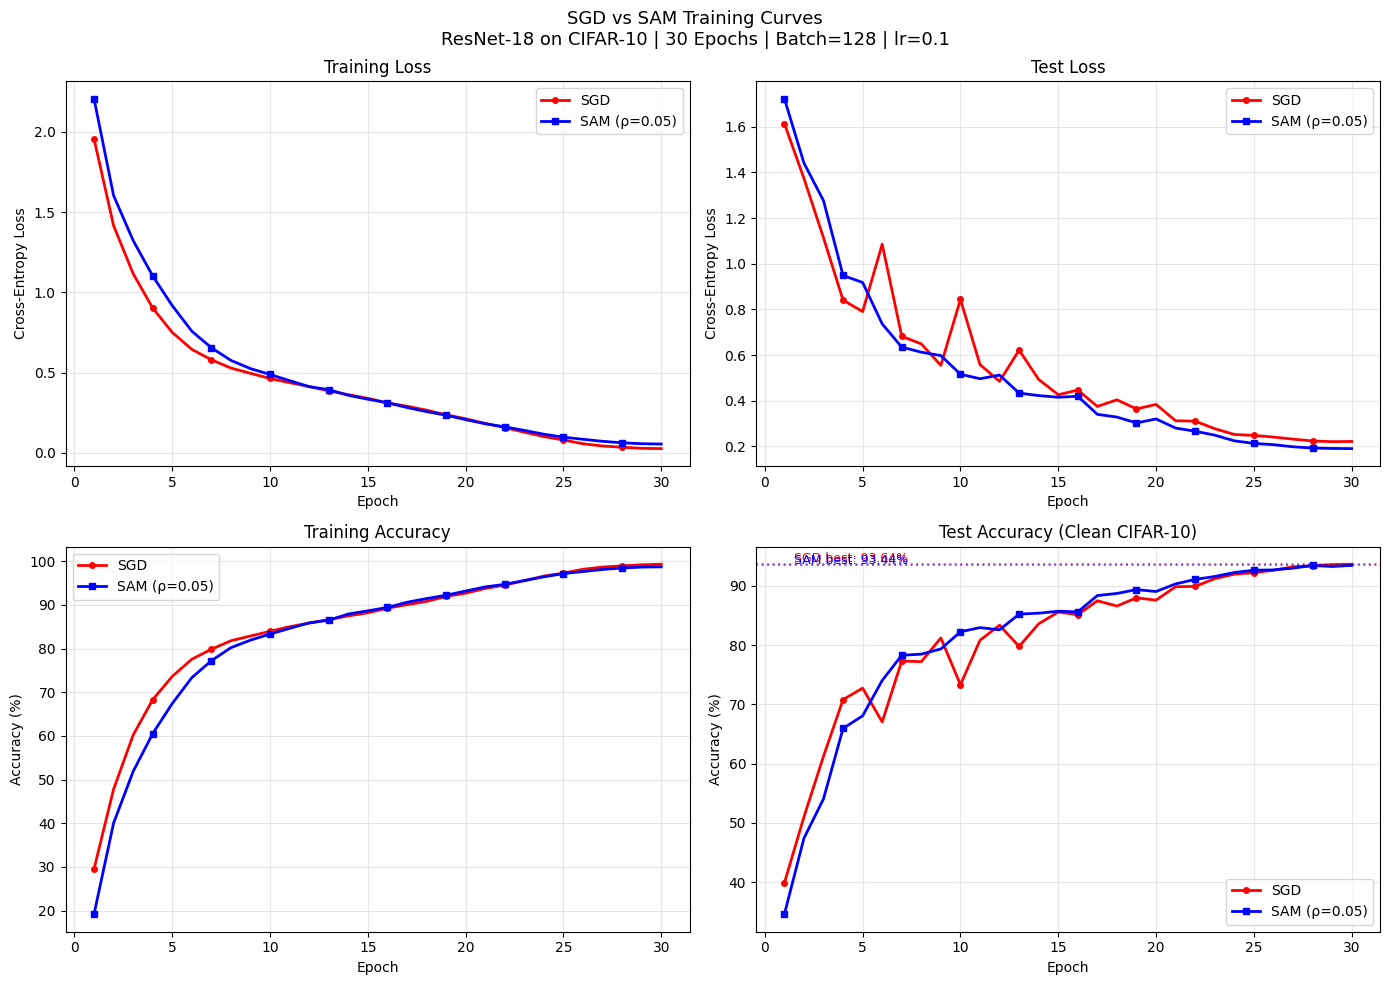


📊 训练结果汇总:
   SGD  — 最终 Test Acc: 93.64%  (最佳: 93.64%)
   SAM  — 最终 Test Acc: 93.44%  (最佳: 93.44%)


In [ ]:
# ============================================================
# CELL 11: 训练曲线对比图（与参考 notebook 风格一致）
# ============================================================

epochs_range = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- 训练损失 ----
ax = axes[0, 0]
ax.plot(epochs_range, sgd_history['train_loss'], 'r-o',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label='SGD')
ax.plot(epochs_range, sam_history['train_loss'], 'b-s',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# ---- 测试损失 ----
ax = axes[0, 1]
ax.plot(epochs_range, sgd_history['test_loss'], 'r-o',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label='SGD')
ax.plot(epochs_range, sam_history['test_loss'], 'b-s',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Test Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# ---- 训练准确率 ----
ax = axes[1, 0]
ax.plot(epochs_range, sgd_history['train_acc'], 'r-o',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label='SGD')
ax.plot(epochs_range, sam_history['train_acc'], 'b-s',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# ---- 测试准确率 ----
ax = axes[1, 1]
ax.plot(epochs_range, sgd_history['test_acc'], 'r-o',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label='SGD')
ax.plot(epochs_range, sam_history['test_acc'], 'b-s',
        markersize=4, linewidth=2, markevery=max(1, EPOCHS//10), label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy (Clean CIFAR-10)')
ax.legend()
ax.grid(True, alpha=0.3)

# 标注最终准确率
sgd_best = max(sgd_history['test_acc'])
sam_best = max(sam_history['test_acc'])
ax.axhline(sgd_best, color='r', linestyle=':', alpha=0.5)
ax.axhline(sam_best, color='b', linestyle=':', alpha=0.5)
ax.text(EPOCHS * 0.05, sgd_best + 0.3, f'SGD best: {sgd_best:.2f}%', color='r', fontsize=9)
ax.text(EPOCHS * 0.05, sam_best + 0.3, f'SAM best: {sam_best:.2f}%', color='b', fontsize=9)

plt.suptitle(f'SGD vs SAM Training Curves\n'
             f'ResNet-18 on CIFAR-10 | {EPOCHS} Epochs | Batch={BATCH_SIZE} | lr={LR}',
             fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 训练结果汇总:')
print(f'   SGD  — 最终 Test Acc: {sgd_history["test_acc"][-1]:.2f}%  (最佳: {sgd_best:.2f}%)')
print(f'   SAM  — 最终 Test Acc: {sam_history["test_acc"][-1]:.2f}%  (最佳: {sam_best:.2f}%)')

---
## PART 3 — OOD 鲁棒性评估（CIFAR-10-C 风格腐蚀）

我们在测试集上手动施加 6 种腐蚀，每种腐蚀有 5 个严重程度，评估两个模型的鲁棒性差异。  
这对应论文中 Exp 1（严重程度敏感性分析）的设计。

| 腐蚀类型 | 模拟现实场景 |
|----------|------------|
| Gaussian Noise | 传感器噪声、低光照 |
| Motion Blur | 相机抖动、快速移动 |
| Brightness | 光照变化 |
| Contrast | 雾、水下 |
| Pixelate | 低分辨率、压缩伪影 |
| Snow | 恶劣天气 |

In [ ]:
# ============================================================
# CELL 12: 腐蚀函数（CIFAR-10-C 风格）
# ============================================================
# 所有函数输入：shape (N, C, H, W) 的 float tensor，值域 [0, 1]（归一化前）
# 输出：相同形状，同样值域
# 腐蚀在归一化之前施加，之后再做 CIFAR-10 的均值/方差归一化

def gaussian_noise(x, severity=3):
    """
    高斯噪声：模拟传感器噪声
    severity 1-5: std = [0.04, 0.06, 0.08, 0.10, 0.12]
    调试: 增大 std 值可增强腐蚀强度
    """
    std_levels = [0.04, 0.06, 0.08, 0.10, 0.12]
    std = std_levels[severity - 1]
    noise = torch.randn_like(x) * std
    return torch.clamp(x + noise, 0.0, 1.0)


def motion_blur(x, severity=3):
    """
    运动模糊：模拟相机抖动
    severity 1-5: kernel_size = [3, 5, 7, 9, 11]
    调试: 增大 kernel_size 可使模糊更强
    """
    kernel_sizes = [3, 5, 7, 9, 11]
    k = kernel_sizes[severity - 1]

    # 构建水平方向运动模糊卷积核
    kernel = torch.zeros(3, 1, 1, k, device=x.device)
    kernel[:, 0, 0, :] = 1.0 / k

    blurred = F.conv2d(x, kernel.view(3, 1, 1, k),
                       padding=(0, k // 2), groups=3)
    return torch.clamp(blurred, 0.0, 1.0)


def brightness_corrupt(x, severity=3):
    """
    亮度增加：模拟曝光过度
    severity 1-5: delta = [0.08, 0.12, 0.18, 0.24, 0.30]
    """
    deltas = [0.08, 0.12, 0.18, 0.24, 0.30]
    return torch.clamp(x + deltas[severity - 1], 0.0, 1.0)


def contrast_corrupt(x, severity=3):
    """
    对比度降低：模拟雾天
    severity 1-5: c = [0.8, 0.6, 0.45, 0.3, 0.15]
    """
    contrasts = [0.80, 0.60, 0.45, 0.30, 0.15]
    c = contrasts[severity - 1]
    mean = x.mean(dim=[2, 3], keepdim=True)  # 各通道均值
    return torch.clamp((x - mean) * c + mean, 0.0, 1.0)


def pixelate(x, severity=3):
    """
    像素化：模拟低分辨率或压缩伪影
    severity 1-5: 下采样尺寸 = [24, 20, 16, 12, 8]
    调试: 减小 size 值可增强像素化程度
    """
    sizes = [24, 20, 16, 12, 8]
    size  = sizes[severity - 1]
    down  = F.interpolate(x, size=(size, size), mode='nearest')
    up    = F.interpolate(down, size=(32, 32), mode='nearest')
    return torch.clamp(up, 0.0, 1.0)


def snow_corrupt(x, severity=3):
    """
    雪花：模拟恶劣天气（亮点+轻微模糊）
    severity 1-5: density = [0.04, 0.07, 0.10, 0.14, 0.18]
    """
    densities = [0.04, 0.07, 0.10, 0.14, 0.18]
    d = densities[severity - 1]
    snow_mask = (torch.rand(x.size(0), 1, 32, 32, device=x.device) < d).float()
    snow_mask = snow_mask.expand_as(x)
    noisy = x + snow_mask * (0.8 + 0.2 * torch.rand_like(x))  # 雪花颜色稍有变化
    # 轻微模糊（降低锯齿感）
    kernel = torch.ones(3, 1, 1, 3, device=x.device) / 3.0
    noisy  = F.conv2d(noisy, kernel.view(3, 1, 1, 3), padding=(0, 1), groups=3)
    return torch.clamp(noisy, 0.0, 1.0)


# 腐蚀类型字典（名称 → 函数）
CORRUPTIONS = {
    'Gaussian\nNoise':  gaussian_noise,
    'Motion\nBlur':     motion_blur,
    'Brightness':       brightness_corrupt,
    'Contrast':         contrast_corrupt,
    'Pixelate':         pixelate,
    'Snow':             snow_corrupt,
}

# CIFAR-10 归一化参数
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
CIFAR_STD  = torch.tensor([0.2470, 0.2435, 0.2616])

print(f'✅ 腐蚀函数定义完成')
print(f'   共 {len(CORRUPTIONS)} 种腐蚀类型 × 5 个严重程度 = {len(CORRUPTIONS)*5} 个评估场景')

✅ 腐蚀函数定义完成
   共 6 种腐蚀类型 × 5 个严重程度 = 30 个评估场景


In [ ]:
# ============================================================
# CELL 13: OOD 鲁棒性评估
# ============================================================

@torch.no_grad()
def evaluate_on_corruption(model, test_loader, corrupt_fn, severity, device):
    """
    在指定腐蚀 + 严重程度上评估模型准确率

    流程：
    1. 加载原始（已归一化）图像
    2. 反归一化 → [0, 1]
    3. 施加腐蚀
    4. 重新归一化
    5. 推断 & 计算准确率
    """
    model.eval()
    correct, total = 0, 0

    mean = CIFAR_MEAN.view(1, 3, 1, 1).to(device)
    std  = CIFAR_STD.view(1, 3, 1, 1).to(device)

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # 反归一化到 [0, 1]
        x = images * std + mean
        x = torch.clamp(x, 0.0, 1.0)

        # 施加腐蚀
        x = corrupt_fn(x, severity=severity)

        # 重新归一化
        x = (x - mean) / std

        outputs = model(x)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)

    return 100.0 * correct / total


# ---- 执行完整评估 ----
print('开始 OOD 鲁棒性评估...')
print('（每个腐蚀类型 × 5 个严重程度，共', len(CORRUPTIONS)*5, '次评估）\n')

# 结果存储：{腐蚀名: {model: [acc_sev1, ..., acc_sev5]}}
results = {}

for c_name, c_fn in CORRUPTIONS.items():
    results[c_name] = {'SGD': [], 'SAM': []}
    display_name = c_name.replace('\n', ' ')
    print(f'评估: {display_name}')

    for sev in range(1, 6):
        sgd_acc = evaluate_on_corruption(sgd_model, test_loader, c_fn, sev, device)
        sam_acc = evaluate_on_corruption(sam_model, test_loader, c_fn, sev, device)
        results[c_name]['SGD'].append(sgd_acc)
        results[c_name]['SAM'].append(sam_acc)
        print(f'   Severity {sev}: SGD={sgd_acc:.1f}%  SAM={sam_acc:.1f}%  '
              f'({"SAM+" if sam_acc > sgd_acc else "SGD+"}{abs(sam_acc-sgd_acc):.1f}%)')

print('\n✅ 评估完成！')

# ---- 计算 mean Corruption Error (mCE) ----
# mCE: 平均腐蚀错误率（越低越好）
# 这里简化为：所有腐蚀 × 所有严重程度的平均错误率
sgd_mCE = np.mean([100 - acc for c in results for acc in results[c]['SGD']])
sam_mCE = np.mean([100 - acc for c in results for acc in results[c]['SAM']])

# 干净测试集准确率
clean_sgd = sgd_history['test_acc'][-1]
clean_sam = sam_history['test_acc'][-1]

print(f'\n📊 OOD 鲁棒性汇总:')
print(f'   干净测试集: SGD={clean_sgd:.2f}%  SAM={clean_sam:.2f}%')
print(f'   mCE (↓越好): SGD={sgd_mCE:.2f}%  SAM={sam_mCE:.2f}%')
print(f'   SAM 相对改善: {sgd_mCE - sam_mCE:+.2f}%')

开始 OOD 鲁棒性评估...
（每个腐蚀类型 × 5 个严重程度，共 30 次评估）

评估: Gaussian Noise
   Severity 1: SGD=80.8%  SAM=77.7%  (SGD+3.0%)
   Severity 2: SGD=62.0%  SAM=55.7%  (SGD+6.4%)
   Severity 3: SGD=42.1%  SAM=34.1%  (SGD+8.1%)
   Severity 4: SGD=27.0%  SAM=20.9%  (SGD+6.1%)
   Severity 5: SGD=19.9%  SAM=15.0%  (SGD+4.9%)
评估: Motion Blur
   Severity 1: SGD=76.9%  SAM=76.2%  (SGD+0.7%)
   Severity 2: SGD=52.3%  SAM=53.7%  (SAM+1.4%)
   Severity 3: SGD=36.7%  SAM=37.4%  (SAM+0.7%)
   Severity 4: SGD=28.9%  SAM=29.9%  (SAM+1.1%)
   Severity 5: SGD=24.7%  SAM=25.8%  (SAM+1.1%)
评估: Brightness
   Severity 1: SGD=93.1%  SAM=93.3%  (SAM+0.1%)
   Severity 2: SGD=92.7%  SAM=92.8%  (SAM+0.2%)
   Severity 3: SGD=92.0%  SAM=92.1%  (SAM+0.1%)
   Severity 4: SGD=90.2%  SAM=90.8%  (SAM+0.6%)
   Severity 5: SGD=87.7%  SAM=89.0%  (SAM+1.2%)
评估: Contrast
   Severity 1: SGD=93.1%  SAM=93.2%  (SAM+0.0%)
   Severity 2: SGD=90.7%  SAM=91.5%  (SAM+0.8%)
   Severity 3: SGD=86.0%  SAM=87.0%  (SAM+1.0%)
   Severity 4: SGD=70.5%  SA

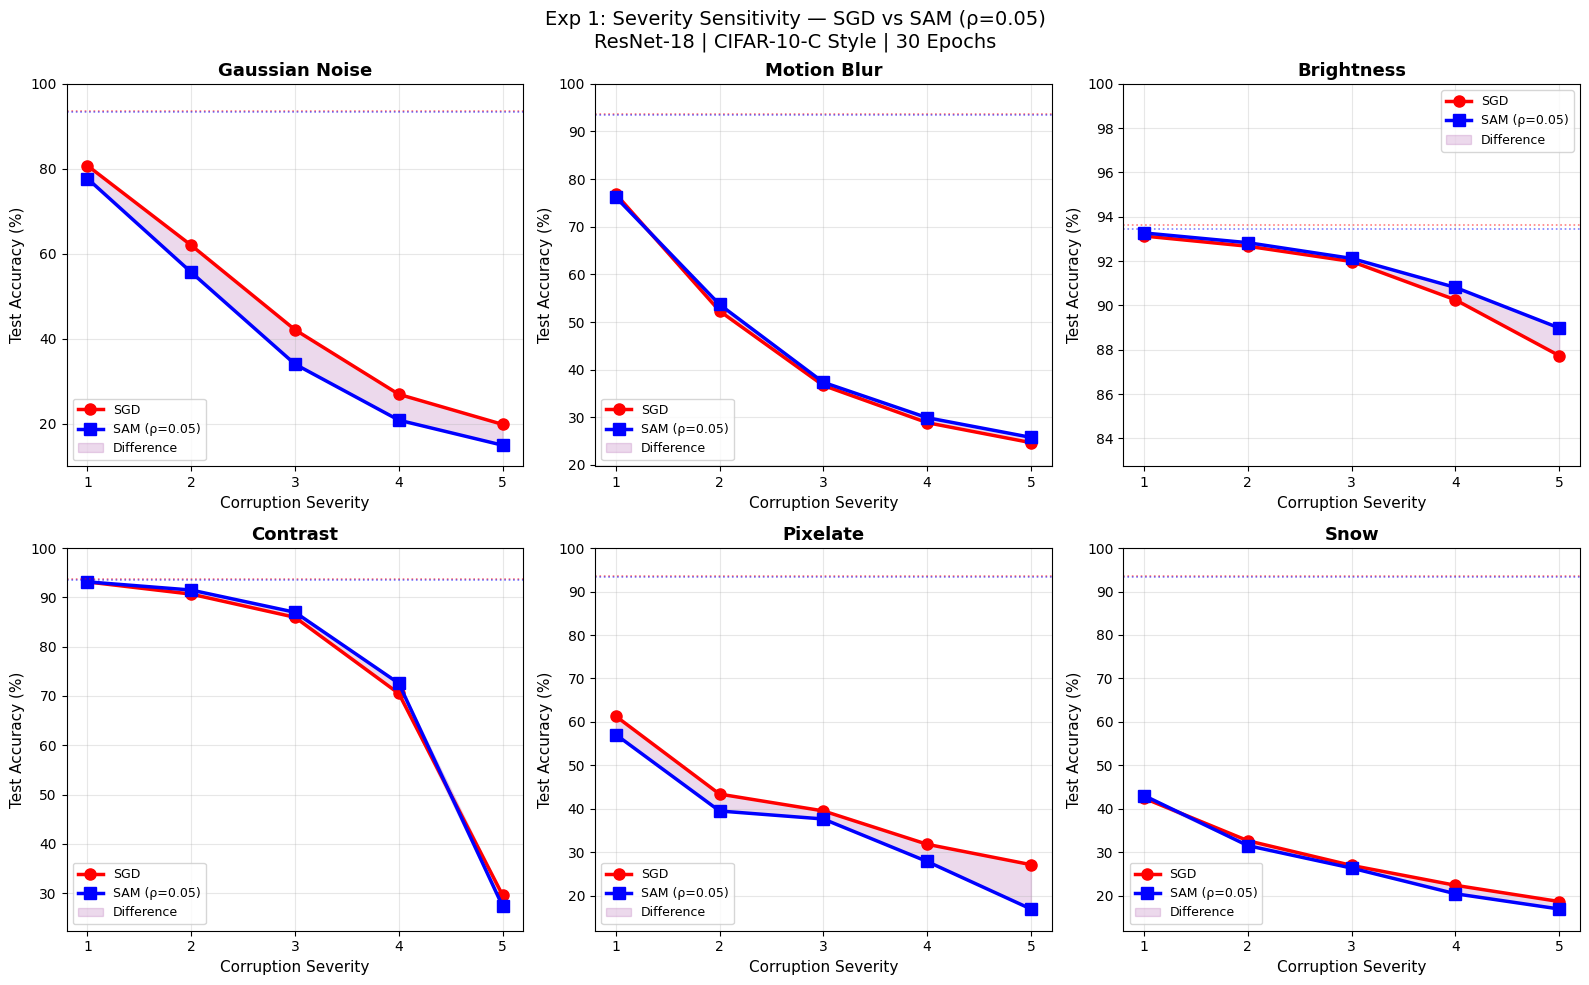

图已保存为 exp1_severity_sensitivity.png


In [ ]:
# ============================================================
# CELL 14: Exp 1 — 严重程度敏感性分析图
# （对应 midterm 中 Exp 1：Track performance decay by severity）
# ============================================================

severity_levels = [1, 2, 3, 4, 5]
n_corruptions   = len(CORRUPTIONS)
corruption_names = list(CORRUPTIONS.keys())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (c_name, ax) in enumerate(zip(corruption_names, axes)):
    sgd_accs = results[c_name]['SGD']
    sam_accs = results[c_name]['SAM']

    ax.plot(severity_levels, sgd_accs, 'r-o', linewidth=2.5,
            markersize=8, label='SGD')
    ax.plot(severity_levels, sam_accs, 'b-s', linewidth=2.5,
            markersize=8, label=f'SAM (ρ={SAM_RHO_TRAIN})')

    # 标注干净基线
    ax.axhline(clean_sgd, color='r', linestyle=':', alpha=0.5, linewidth=1.2)
    ax.axhline(clean_sam, color='b', linestyle=':', alpha=0.5, linewidth=1.2)

    # 填充两条曲线之间的差异区域
    ax.fill_between(severity_levels,
                    [min(s, g) for s, g in zip(sam_accs, sgd_accs)],
                    [max(s, g) for s, g in zip(sam_accs, sgd_accs)],
                    alpha=0.15, color='purple', label='Difference')

    display_name = c_name.replace('\n', ' ')
    ax.set_title(display_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Corruption Severity', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.set_xticks(severity_levels)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(max(0, min(min(sgd_accs), min(sam_accs)) - 5), 100)

plt.suptitle(
    f'Exp 1: Severity Sensitivity — SGD vs SAM (ρ={SAM_RHO_TRAIN})\n'
    f'ResNet-18 | CIFAR-10-C Style | {EPOCHS} Epochs',
    fontsize=14
)
plt.tight_layout()
plt.savefig('exp1_severity_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存为 exp1_severity_sensitivity.png')

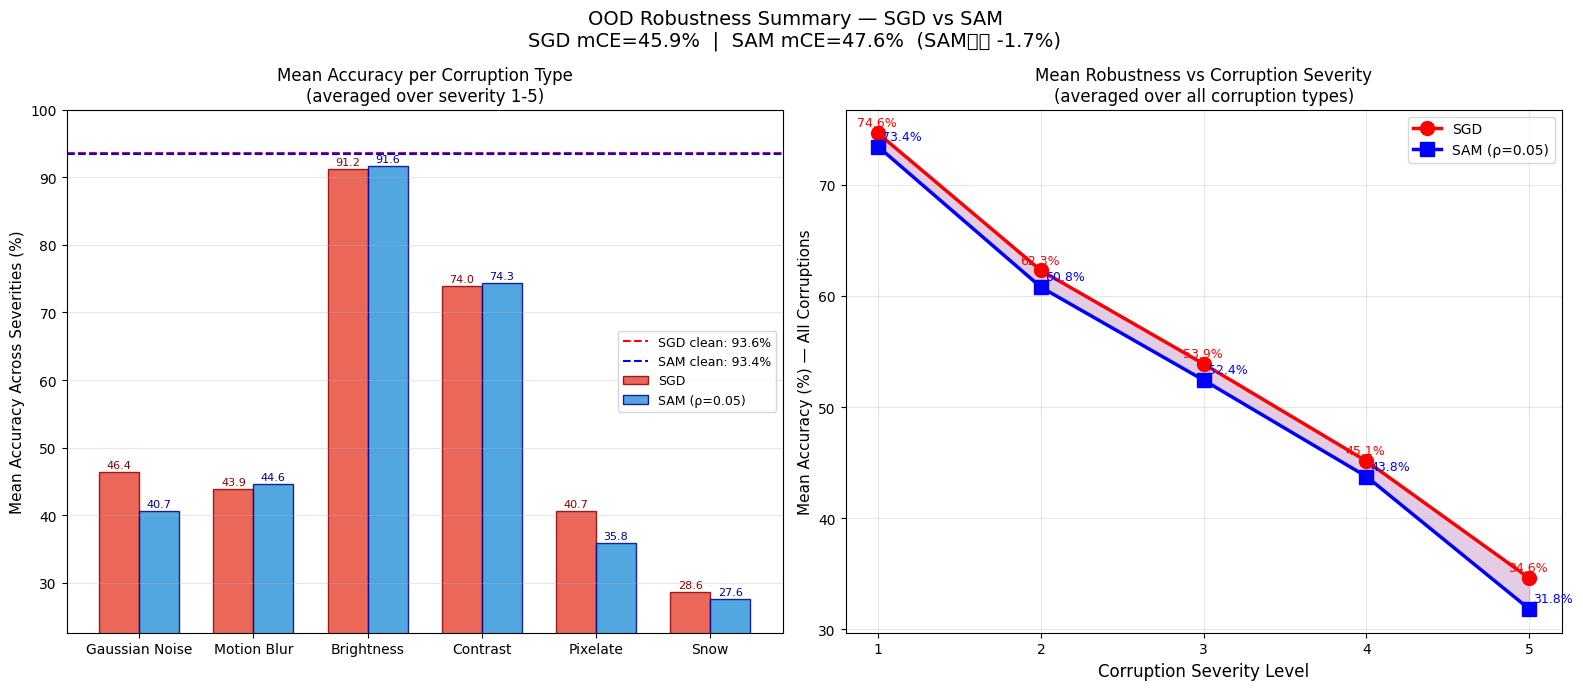

图已保存为 robustness_summary.png


In [ ]:
# ============================================================
# CELL 15: 综合对比图（雷达图 + 柱状图）
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---- 左图：各腐蚀平均准确率柱状图 ----
ax = axes[0]

display_names = [c.replace('\n', ' ') for c in corruption_names]
sgd_mean_per_corruption = [np.mean(results[c]['SGD']) for c in corruption_names]
sam_mean_per_corruption = [np.mean(results[c]['SAM']) for c in corruption_names]

x = np.arange(len(corruption_names))
width = 0.35
bars_sgd = ax.bar(x - width/2, sgd_mean_per_corruption, width,
                   color='#E74C3C', alpha=0.85, label='SGD', edgecolor='darkred')
bars_sam = ax.bar(x + width/2, sam_mean_per_corruption, width,
                   color='#3498DB', alpha=0.85, label=f'SAM (ρ={SAM_RHO_TRAIN})', edgecolor='darkblue')

# 标注数值
for bar in bars_sgd:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='darkred')
for bar in bars_sam:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='darkblue')

# 干净基线
ax.axhline(clean_sgd, color='r', linestyle='--', linewidth=1.5,
            label=f'SGD clean: {clean_sgd:.1f}%')
ax.axhline(clean_sam, color='b', linestyle='--', linewidth=1.5,
            label=f'SAM clean: {clean_sam:.1f}%')

ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=10)
ax.set_ylabel('Mean Accuracy Across Severities (%)', fontsize=11)
ax.set_title('Mean Accuracy per Corruption Type\n(averaged over severity 1-5)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(max(0, min(min(sgd_mean_per_corruption), min(sam_mean_per_corruption)) - 5), 100)

# ---- 右图：各严重程度平均准确率折线图 ----
ax2 = axes[1]

sgd_mean_per_severity = [
    np.mean([results[c]['SGD'][s] for c in corruption_names])
    for s in range(5)
]
sam_mean_per_severity = [
    np.mean([results[c]['SAM'][s] for c in corruption_names])
    for s in range(5)
]

ax2.plot(severity_levels, sgd_mean_per_severity, 'r-o',
          linewidth=2.5, markersize=10, label='SGD')
ax2.plot(severity_levels, sam_mean_per_severity, 'b-s',
          linewidth=2.5, markersize=10, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax2.fill_between(severity_levels,
                  [min(s, g) for s, g in zip(sam_mean_per_severity, sgd_mean_per_severity)],
                  [max(s, g) for s, g in zip(sam_mean_per_severity, sgd_mean_per_severity)],
                  alpha=0.2, color='purple')

# 标注数值
for s, (sg, sm) in enumerate(zip(sgd_mean_per_severity, sam_mean_per_severity)):
    ax2.annotate(f'{sg:.1f}%', (s+1, sg), textcoords='offset points',
                  xytext=(-15, 5), fontsize=9, color='r')
    ax2.annotate(f'{sm:.1f}%', (s+1, sm), textcoords='offset points',
                  xytext=(3, 5), fontsize=9, color='b')

ax2.set_xlabel('Corruption Severity Level', fontsize=12)
ax2.set_ylabel('Mean Accuracy (%) — All Corruptions', fontsize=11)
ax2.set_title('Mean Robustness vs Corruption Severity\n(averaged over all corruption types)', fontsize=12)
ax2.set_xticks(severity_levels)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'OOD Robustness Summary — SGD vs SAM\n'
    f'SGD mCE={sgd_mCE:.1f}%  |  SAM mCE={sam_mCE:.1f}%  '
    f'(SAM改善 {sgd_mCE-sam_mCE:+.1f}%)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('robustness_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存为 robustness_summary.png')

Exp 2 — ρ 消融实验 (15 epochs each)
测试 ρ 值: [0.01, 0.05, 0.1, 0.2]

--- ρ = 0.01 ---
   Clean Acc=90.43%  |  Approx mCE=49.61%
--- ρ = 0.05 ---
   Clean Acc=90.24%  |  Approx mCE=50.51%
--- ρ = 0.1 ---
   Clean Acc=89.28%  |  Approx mCE=50.35%
--- ρ = 0.2 ---
   Clean Acc=85.28%  |  Approx mCE=54.91%


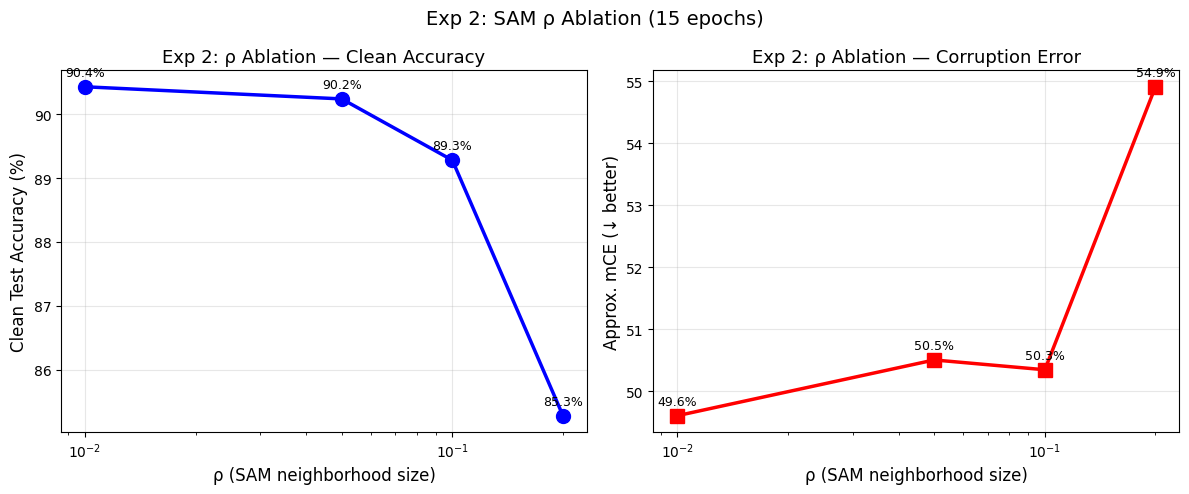

图已保存为 exp2_rho_ablation.png


In [ ]:
# ============================================================
# CELL 16: Exp 2 — ρ 消融实验（SAM 超参数敏感性分析）
# 注意：此 cell 需要重新训练多个 SAM 模型，运行时间较长
# 如时间有限，可跳过此 cell
# ============================================================

# 调试哪些参数：
#   RHO_VALUES: 你想要测试的 ρ 值列表
#   ABLATION_EPOCHS: 消融实验轮数（建议 10-20，快速评估趋势）
RHO_VALUES      = [0.01, 0.05, 0.1, 0.2]  # 测试的 ρ 值
ABLATION_EPOCHS = 15                        # 消融轮数（比完整训练短）

criterion = nn.CrossEntropyLoss()
ablation_results = {}  # {rho: {'test_acc': float, 'mCE': float}}

print(f'Exp 2 — ρ 消融实验 ({ABLATION_EPOCHS} epochs each)')
print(f'测试 ρ 值: {RHO_VALUES}\n')

for rho_val in RHO_VALUES:
    print(f'--- ρ = {rho_val} ---')

    # 初始化新模型（相同随机种子保证可比性）
    torch.manual_seed(42)
    abl_model = get_resnet18_cifar().to(device)

    abl_opt = SAM(
        abl_model.parameters(),
        torch.optim.SGD,
        rho=rho_val,
        lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
    )
    abl_sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        abl_opt.base_optimizer, T_max=ABLATION_EPOCHS)

    # 训练
    for ep in range(ABLATION_EPOCHS):
        train_one_epoch_sam(abl_model, train_loader, abl_opt, abl_sch,
                             criterion, device)

    # 评估干净测试集
    _, clean_acc = evaluate(abl_model, test_loader, criterion, device)

    # 评估腐蚀（只用 severity=3 快速估计 mCE）
    corruption_accs = []
    for c_fn in CORRUPTIONS.values():
        for sev in [2, 3, 4]:  # 只测 3 个中间严重程度
            acc = evaluate_on_corruption(abl_model, test_loader, c_fn, sev, device)
            corruption_accs.append(acc)

    mce_approx = 100 - np.mean(corruption_accs)
    ablation_results[rho_val] = {'test_acc': clean_acc, 'mCE': mce_approx}
    print(f'   Clean Acc={clean_acc:.2f}%  |  Approx mCE={mce_approx:.2f}%')

# ---- 绘制消融图 ----
rho_vals  = list(ablation_results.keys())
clean_accs = [ablation_results[r]['test_acc'] for r in rho_vals]
mce_vals  = [ablation_results[r]['mCE'] for r in rho_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(rho_vals, clean_accs, 'b-o', linewidth=2.5, markersize=10)
ax1.set_xlabel('ρ (SAM neighborhood size)', fontsize=12)
ax1.set_ylabel('Clean Test Accuracy (%)', fontsize=12)
ax1.set_title('Exp 2: ρ Ablation — Clean Accuracy', fontsize=13)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
for r, a in zip(rho_vals, clean_accs):
    ax1.annotate(f'{a:.1f}%', (r, a), textcoords='offset points',
                  xytext=(0, 8), ha='center', fontsize=9)

ax2.plot(rho_vals, mce_vals, 'r-s', linewidth=2.5, markersize=10)
ax2.set_xlabel('ρ (SAM neighborhood size)', fontsize=12)
ax2.set_ylabel('Approx. mCE (↓ better)', fontsize=12)
ax2.set_title('Exp 2: ρ Ablation — Corruption Error', fontsize=13)
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
for r, m in zip(rho_vals, mce_vals):
    ax2.annotate(f'{m:.1f}%', (r, m), textcoords='offset points',
                  xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle(f'Exp 2: SAM ρ Ablation ({ABLATION_EPOCHS} epochs)', fontsize=14)
plt.tight_layout()
plt.savefig('exp2_rho_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存为 exp2_rho_ablation.png')

In [ ]:
# ============================================================
# CELL 17: 超参数网格搜索 — 自动循环所有参数组合
# ============================================================
import itertools

# ====================================================================
# ★★★  在这里定义你要搜索的参数列表  ★★★
# 每个列表里可以放任意多个值，脚本会自动组合所有可能
# ====================================================================
sweep_lr  = [0.05, 0.1]          # 初始学习率
sweep_rho = [0.01, 0.05, 0.1, 0.2]  # SAM ρ
sweep_wd  = [1e-4, 5e-4]         # Weight decay

SWEEP_EPOCHS   = 10   # 每组配置训练轮数（快速筛选，不需要完整收敛）
SWEEP_MOMENTUM = 0.9  # 固定 momentum，不参与搜索
# ====================================================================

# 生成所有参数组合
param_grid = list(itertools.product(sweep_lr, sweep_rho, sweep_wd))
n_configs  = len(param_grid)
print(f'共 {len(sweep_lr)} LR × {len(sweep_rho)} ρ × {len(sweep_wd)} WD'
      f' = {n_configs} 组配置 × {SWEEP_EPOCHS} epochs')
print(f'预计时间: ~{n_configs * SWEEP_EPOCHS * 30 / 60:.0f} 分钟（T4 GPU）\n')

# 结果存储
sweep_results = []   # list of dict: {lr, rho, wd, clean_acc, mce_approx}
criterion_sw  = nn.CrossEntropyLoss()

t_sweep_start = time.time()

for cfg_idx, (lr_val, rho_val, wd_val) in enumerate(param_grid, 1):
    cfg_tag = f'[{cfg_idx:02d}/{n_configs}] lr={lr_val:.3f} ρ={rho_val:.3f} wd={wd_val:.0e}'
    print(f'\n{cfg_tag}')
    print('-' * 50)

    # ---------- 初始化模型（固定种子保证可比性） ----------
    torch.manual_seed(42)
    sw_model = get_resnet18_cifar().to(device)

    sw_opt = SAM(
        sw_model.parameters(),
        torch.optim.SGD,
        rho=rho_val,
        lr=lr_val,
        momentum=SWEEP_MOMENTUM,
        weight_decay=wd_val
    )
    sw_sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        sw_opt.base_optimizer, T_max=SWEEP_EPOCHS, eta_min=0
    )

    # ---------- 快速训练 ----------
    best_acc = 0.0
    for ep in range(1, SWEEP_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch_sam(
            sw_model, train_loader, sw_opt, sw_sch, criterion_sw, device)
        _, te_acc = evaluate(sw_model, test_loader, criterion_sw, device)
        best_acc = max(best_acc, te_acc)
        if ep % 5 == 0 or ep == SWEEP_EPOCHS:
            print(f'  ep {ep:02d}: train_acc={tr_acc:.1f}%  test_acc={te_acc:.1f}%')

    # ---------- 快速 OOD 评估（severity=3，所有腐蚀类型） ----------
    ood_accs = []
    for c_fn in CORRUPTIONS.values():
        acc = evaluate_on_corruption(sw_model, test_loader, c_fn, severity=3, device=device)
        ood_accs.append(acc)
    mce_approx = 100 - np.mean(ood_accs)

    # ---------- 记录结果 ----------
    elapsed = time.time() - t_sweep_start
    eta     = elapsed / cfg_idx * (n_configs - cfg_idx)
    sweep_results.append({
        'lr': lr_val, 'rho': rho_val, 'wd': wd_val,
        'clean_acc': best_acc, 'mce': mce_approx
    })
    print(f'  => Best clean acc: {best_acc:.2f}%  |  Approx mCE: {mce_approx:.2f}%'
          f'  |  ETA: {eta/60:.1f}min')

# ============================================================
# 汇总：按 clean_acc 降序排列，打印完整排名表
# ============================================================
sweep_results.sort(key=lambda x: x['clean_acc'], reverse=True)

print('\n' + '='*70)
print(f'  超参数搜索结果排名（共 {n_configs} 组，按 Clean Acc 降序）')
print('='*70)
print(f'  {"Rank":>4} | {"LR":>6} | {"ρ":>6} | {"WD":>8} | {"Clean Acc":>10} | {"Approx mCE":>11}')
print('-'*70)
for rank, r in enumerate(sweep_results, 1):
    marker = ' ★' if rank == 1 else ('  ' if rank > 3 else '  ▲')
    print(f'  {rank:>4} | {r["lr"]:>6.3f} | {r["rho"]:>6.3f} | {r["wd"]:>8.0e} '
          f'| {r["clean_acc"]:>9.2f}% | {r["mce"]:>10.2f}%{marker}')
print('='*70)

best = sweep_results[0]
print(f'\n  最佳配置: lr={best["lr"]}  ρ={best["rho"]}  wd={best["wd"]:.0e}')
print(f'  Clean Acc={best["clean_acc"]:.2f}%  |  Approx mCE={best["mce"]:.2f}%')
print(f'\n  总耗时: {(time.time()-t_sweep_start)/60:.1f} 分钟')

共 2 LR × 4 ρ × 2 WD = 16 组配置 × 10 epochs
预计时间: ~80 分钟（T4 GPU）


[01/16] lr=0.050 ρ=0.010 wd=1e-04
--------------------------------------------------
  ep 05: train_acc=80.3%  test_acc=79.5%
  ep 10: train_acc=90.1%  test_acc=87.4%
  => Best clean acc: 87.38%  |  Approx mCE: 46.58%  |  ETA: 36.7min

[02/16] lr=0.050 ρ=0.010 wd=5e-04
--------------------------------------------------
  ep 05: train_acc=80.6%  test_acc=78.4%
  ep 10: train_acc=91.4%  test_acc=88.4%
  => Best clean acc: 88.44%  |  Approx mCE: 47.96%  |  ETA: 34.0min

[03/16] lr=0.050 ρ=0.050 wd=1e-04
--------------------------------------------------
  ep 05: train_acc=78.5%  test_acc=78.4%
  ep 10: train_acc=88.1%  test_acc=86.1%
  => Best clean acc: 86.08%  |  Approx mCE: 47.92%  |  ETA: 31.4min

[04/16] lr=0.050 ρ=0.050 wd=5e-04
--------------------------------------------------
  ep 05: train_acc=78.3%  test_acc=78.5%
  ep 10: train_acc=89.3%  test_acc=87.3%
  => Best clean acc: 87.31%  |  Approx mCE: 48.23%  |  ETA: 2

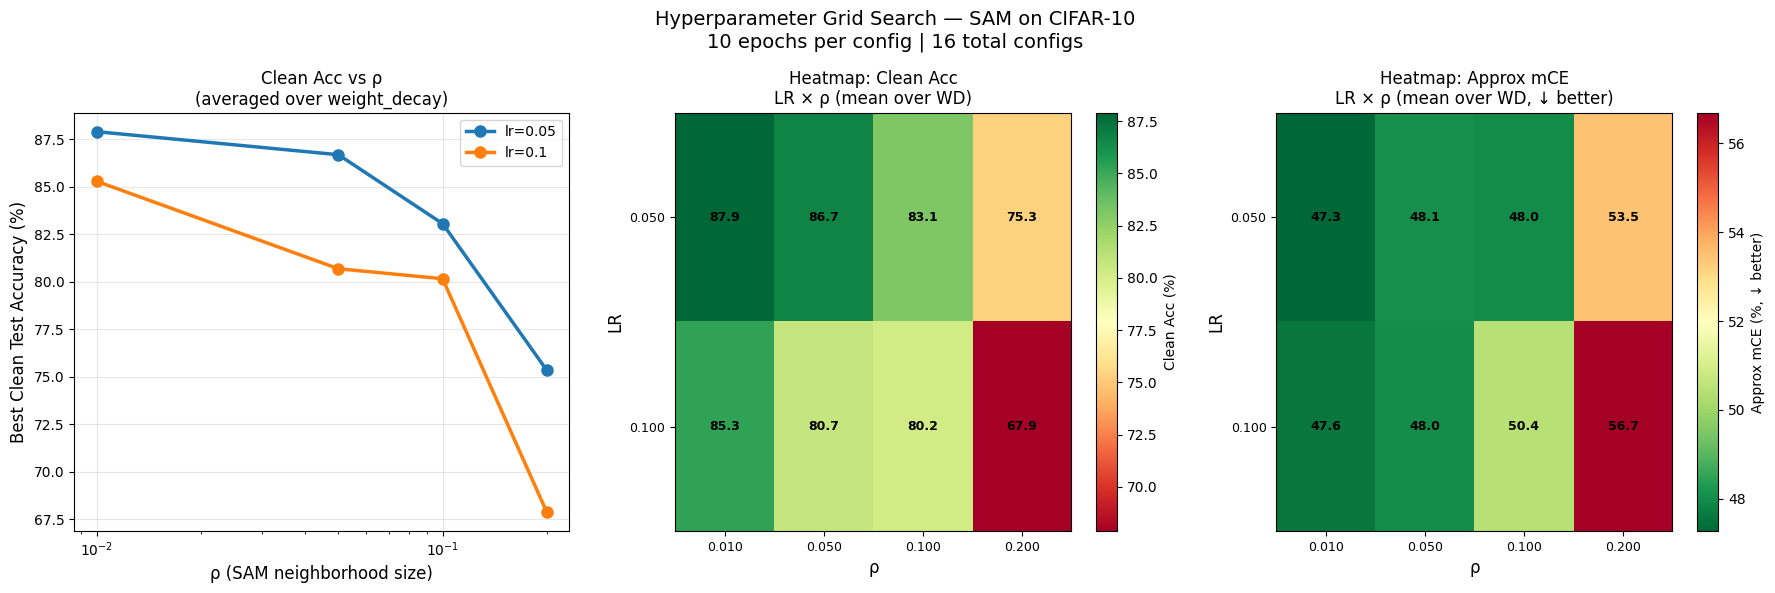


推荐配置 Top-3（按 Clean Acc）:
  #1: lr=0.05  ρ=0.01  wd=5e-04  →  CleanAcc=88.44%  mCE=47.96%
  #2: lr=0.05  ρ=0.01  wd=1e-04  →  CleanAcc=87.38%  mCE=46.58%
  #3: lr=0.05  ρ=0.05  wd=5e-04  →  CleanAcc=87.31%  mCE=48.23%

将上方最佳参数填入 CELL 7 的 LR / SAM_RHO_TRAIN / WEIGHT_DECAY 再做完整训练。
图已保存为 sweep_results.png


In [ ]:
# ============================================================
# CELL 18: 超参数搜索结果可视化
# ============================================================

import pandas as pd

df = pd.DataFrame(sweep_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---- 左图：各 ρ 下的 Clean Acc（按 LR 分组） ----
ax = axes[0]
for lr_v in sorted(df['lr'].unique()):
    sub = df[df['lr'] == lr_v].groupby('rho')['clean_acc'].mean().reset_index()
    ax.plot(sub['rho'], sub['clean_acc'], '-o', linewidth=2.5,
            markersize=8, label=f'lr={lr_v}')
ax.set_xscale('log')
ax.set_xlabel('ρ (SAM neighborhood size)', fontsize=12)
ax.set_ylabel('Best Clean Test Accuracy (%)', fontsize=12)
ax.set_title('Clean Acc vs ρ\n(averaged over weight_decay)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- 中图：heatmap — LR × ρ 的 Clean Acc ----
ax = axes[1]
pivot_acc = df.groupby(['lr', 'rho'])['clean_acc'].mean().unstack()
im = ax.imshow(pivot_acc.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Clean Acc (%)')
ax.set_xticks(range(len(pivot_acc.columns)))
ax.set_xticklabels([f'{v:.3f}' for v in pivot_acc.columns], fontsize=9)
ax.set_yticks(range(len(pivot_acc.index)))
ax.set_yticklabels([f'{v:.3f}' for v in pivot_acc.index], fontsize=9)
ax.set_xlabel('ρ', fontsize=12)
ax.set_ylabel('LR', fontsize=12)
ax.set_title('Heatmap: Clean Acc\nLR × ρ (mean over WD)', fontsize=12)
for i in range(len(pivot_acc.index)):
    for j in range(len(pivot_acc.columns)):
        ax.text(j, i, f'{pivot_acc.values[i, j]:.1f}',
                ha='center', va='center', fontsize=9, fontweight='bold')

# ---- 右图：heatmap — LR × ρ 的 Approx mCE ----
ax = axes[2]
pivot_mce = df.groupby(['lr', 'rho'])['mce'].mean().unstack()
im2 = ax.imshow(pivot_mce.values, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im2, ax=ax, label='Approx mCE (%, ↓ better)')
ax.set_xticks(range(len(pivot_mce.columns)))
ax.set_xticklabels([f'{v:.3f}' for v in pivot_mce.columns], fontsize=9)
ax.set_yticks(range(len(pivot_mce.index)))
ax.set_yticklabels([f'{v:.3f}' for v in pivot_mce.index], fontsize=9)
ax.set_xlabel('ρ', fontsize=12)
ax.set_ylabel('LR', fontsize=12)
ax.set_title('Heatmap: Approx mCE\nLR × ρ (mean over WD, ↓ better)', fontsize=12)
for i in range(len(pivot_mce.index)):
    for j in range(len(pivot_mce.columns)):
        ax.text(j, i, f'{pivot_mce.values[i, j]:.1f}',
                ha='center', va='center', fontsize=9, fontweight='bold')

plt.suptitle(
    f'Hyperparameter Grid Search — SAM on CIFAR-10\n'
    f'{SWEEP_EPOCHS} epochs per config | {n_configs} total configs',
    fontsize=14
)
plt.tight_layout()
plt.savefig('sweep_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 打印 Top-3 推荐配置 ----
print('\n推荐配置 Top-3（按 Clean Acc）:')
for i, r in enumerate(sweep_results[:3], 1):
    print(f'  #{i}: lr={r["lr"]}  ρ={r["rho"]}  wd={r["wd"]:.0e}'
          f'  →  CleanAcc={r["clean_acc"]:.2f}%  mCE={r["mce"]:.2f}%')
print('\n将上方最佳参数填入 CELL 7 的 LR / SAM_RHO_TRAIN / WEIGHT_DECAY 再做完整训练。')
print('图已保存为 sweep_results.png')

---
## PART 4 — 超参数网格搜索（自动循环所有参数组合）

在这里预先固定你想比较的参数值，脚本会**自动循环所有组合**，用快速训练（`SWEEP_EPOCHS`）评估每组配置，最终输出排名表格和可视化对比。

| 参数 | 含义 | 推荐搜索范围 |
|------|------|-------------|
| `sweep_lr` | 初始学习率 | [0.05, 0.1, 0.2] |
| `sweep_rho` | SAM 扰动半径 ρ | [0.01, 0.05, 0.1, 0.2] |
| `sweep_wd` | Weight decay (L2) | [1e-4, 5e-4, 1e-3] |
| `SWEEP_EPOCHS` | 每组配置训练轮数 | 10–20（快速筛选）|

> ⏱️ **时间估算**：2 LR × 4 ρ × 2 WD = **16 组** × 10 epochs × ~30s ≈ **80 分钟**（T4 GPU）  
> 减少 `sweep_wd` 或 `sweep_rho` 的值可以显著缩短时间

In [ ]:
# ============================================================
# CELL 19: 最终结果汇总表
# ============================================================

print('\n' + '='*65)
print('  FINAL RESULTS SUMMARY')
print('='*65)
print(f'  Model Architecture : ResNet-18 (CIFAR-adapted)')
print(f'  Training Epochs    : {EPOCHS}')
print(f'  Batch Size         : {BATCH_SIZE}')
print(f'  Learning Rate      : {LR}')
print(f'  Momentum           : {MOMENTUM}')
print(f'  Weight Decay       : {WEIGHT_DECAY}')
print(f'  SAM ρ              : {SAM_RHO_TRAIN}')
print('='*65)
print(f'  {"Metric":<35} {"SGD":>8} {"SAM":>8} {"Δ":>8}')
print('-'*65)
print(f'  {"Clean Test Accuracy":35} {clean_sgd:>7.2f}% {clean_sam:>7.2f}% {clean_sam-clean_sgd:>+7.2f}%')
print(f'  {"Mean Corruption Error (mCE)":35} {sgd_mCE:>7.2f}% {sam_mCE:>7.2f}% {sam_mCE-sgd_mCE:>+7.2f}%')
print('-'*65)

for c_name in corruption_names:
    display = c_name.replace('\n', ' ')
    sgd_m = np.mean(results[c_name]['SGD'])
    sam_m = np.mean(results[c_name]['SAM'])
    print(f'  Mean Acc: {display:<25} {sgd_m:>7.2f}% {sam_m:>7.2f}% {sam_m-sgd_m:>+7.2f}%')

print('='*65)
print('  Δ > 0: SAM better | Δ < 0: SGD better')
print('  mCE Δ < 0: SAM has lower corruption error (better robustness)')
print('='*65)


  FINAL RESULTS SUMMARY
  Model Architecture : ResNet-18 (CIFAR-adapted)
  Training Epochs    : 30
  Batch Size         : 128
  Learning Rate      : 0.1
  Momentum           : 0.9
  Weight Decay       : 0.0005
  SAM ρ              : 0.05
  Metric                                   SGD      SAM        Δ
-----------------------------------------------------------------
  Clean Test Accuracy                   93.64%   93.44%   -0.20%
  Mean Corruption Error (mCE)           45.90%   47.56%   +1.66%
-----------------------------------------------------------------
  Mean Acc: Gaussian Noise              46.36%   40.67%   -5.69%
  Mean Acc: Motion Blur                 43.90%   44.60%   +0.70%
  Mean Acc: Brightness                  91.15%   91.60%   +0.45%
  Mean Acc: Contrast                    73.98%   74.32%   +0.34%
  Mean Acc: Pixelate                    40.65%   35.83%   -4.83%
  Mean Acc: Snow                        28.59%   27.63%   -0.96%
  Δ > 0: SAM better | Δ < 0: SGD better
  mC

---
## 📋 参数调试完整指南

### 🎯 如何让 2D/3D 轨迹图的差异更明显

**问题：两条轨迹看起来太相似**  
→ 增大 `VALLEY_SHARPNESS`（试 10 → 30 → 50）  
→ 增大 `SAM_RHO_TOY`（试 0.5 → 0.8 → 1.2）  
→ 换起始点到更偏轴的位置：`START_POINT = [5, 1]` 或 `[-4, 3]`  
→ 增大迭代步数：`N_STEPS_TOY = 120`

**问题：SAM 轨迹发散（飞出图外）**  
→ 减小 `SAM_RHO_TOY`（试 0.3 → 0.2 → 0.1）  
→ 减小 `SGD_LR_TOY` / `SAM_LR_TOY`（试 0.04 → 0.03）  
→ 确保 `VALLEY_SHARPNESS` × `SAM_LR_TOY` < 1  

**问题：轨迹步长太小，看不清路径细节**  
→ 在 contour 绘制中减小 `step_mark`（改 `//15` 为 `//8`）

**问题：3D 图中轨迹被曲面遮挡**  
→ 调整相机角度：修改 `ax.view_init(elev=XX, azim=YY)`  
→ 增大曲面透明度：`alpha=0.3`（更透明）

---

### 🎯 如何让 CIFAR-10 训练效果更好

**想让 SAM 优势更明显**  
→ 增大 `EPOCHS`（30 → 100 → 200）：短训练时 SAM 优势不明显  
→ 尝试 `SAM_RHO_TRAIN = 0.1`（比默认 0.05 更激进）  
→ 将 `adaptive=True`（ASAM，通常更稳定）

**想加快训练速度（Colab 时间有限）**  
→ 减小 `EPOCHS = 10`（趋势已可见）  
→ 减小 `BATCH_SIZE = 256`（每轮更少步，但每步更大）  

**想要完整复现论文结果**  
→ `EPOCHS = 200`, `LR = 0.1`, `SAM_RHO_TRAIN = 0.05`  
→ 需要 Kaggle/A100，约 2-3 小时

---

### 🎯 实验参数总览

| 所在 Cell | 参数名 | 含义 | 调试建议 |
|-----------|--------|------|----------|
| Cell 2 | `VALLEY_SHARPNESS` | 峡谷陡峭度 | 5→20：轨迹差异更大 |
| Cell 2 | `SAM_RHO_TOY` | 玩具 SAM ρ | 0.5→1.0：路径更不同 |
| Cell 2 | `SGD_LR_TOY` / `SAM_LR_TOY` | 玩具学习率 | 过大则不收敛 |
| Cell 2 | `N_STEPS_TOY` | 优化步数 | 80→150：更完整路径 |
| Cell 2 | `START_POINT` | 起始点 | [4,3] → [5,1] |
| Cell 7 | `EPOCHS` | 训练轮数 | 30→100：更明显差异 |
| Cell 7 | `LR` | 学习率 | 0.1（标准）|
| Cell 7 | `SAM_RHO_TRAIN` | 训练 ρ | 0.05→0.1 |
| Cell 7 | `BATCH_SIZE` | 批大小 | OOM 时用 64 |
| Cell 16 | `RHO_VALUES` | 消融 ρ 列表 | 按需修改 |
| Cell 16 | `ABLATION_EPOCHS` | 消融轮数 | 10-20 |
